# 🫀 Projeto - Classificação com KNN | Dataset do Coração

In [1]:
# Importando bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

## Carregamento dos Dados

In [2]:
# Fonte do Dataset: https://raw.githubusercontent.com/professortiagoinfnet/inteligencia_artificial/main/heart.csv
# Carregando os dados do diretório local
arquivo_dataset = 'heart.csv'
dados = pd.read_csv(arquivo_dataset)

# Visualizando as primeiras linhas
dados.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## Identificação de Features e Target

In [3]:
# Conferindo o nome das colunas
print(dados.columns)

# Verificando se a coluna 'HeartDisease' existe
if 'HeartDisease' in dados.columns:
    features = dados.drop('HeartDisease', axis=1)
    target = dados['HeartDisease']
else:
    print("Coluna 'HeartDisease' não encontrada. Verifique o nome correto nas colunas acima.")

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')


## Divisão dos Dados (80% treino | 20% validação)

In [4]:
X_treino, X_validacao, y_treino, y_validacao = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42,
    stratify=target
)

## Pipeline de Padronização

In [5]:
def preparar_pipeline(features):
    colunas_numericas = features.select_dtypes(include=['int64', 'float64']).columns
    colunas_categoricas = features.select_dtypes(include=['object']).columns

    pipeline = ColumnTransformer(transformers=[
        ('num', StandardScaler(), colunas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), colunas_categoricas)
    ])

    features_transformadas = pipeline.fit_transform(features)
    return features_transformadas, pipeline

X_treino_pad, pipeline = preparar_pipeline(X_treino)
X_validacao_pad = pipeline.transform(X_validacao)

## Pipeline de Modelagem KNN

In [6]:
def treinar_knn(X_treino, y_treino, k=5):
    modelo = KNeighborsClassifier(n_neighbors=k)
    modelo.fit(X_treino, y_treino)
    return modelo

## Avaliação do Modelo

In [7]:
def avaliar_modelo(modelo, X_validacao, y_validacao):
    predicoes = modelo.predict(X_validacao)
    acuracia = accuracy_score(y_validacao, predicoes)
    return acuracia

## Análise de Parâmetros (Variação de K)

In [8]:
def analisar_parametro_k(X_treino, y_treino, X_validacao, y_validacao, k_max=20):
    resultados = []

    for k in range(1, k_max + 1):
        modelo = treinar_knn(X_treino, y_treino, k)
        acuracia = avaliar_modelo(modelo, X_validacao, y_validacao)
        resultados.append((k, acuracia))

    return pd.DataFrame(resultados, columns=['K', 'Acuracia'])

resultados_k = analisar_parametro_k(X_treino_pad, y_treino, X_validacao_pad, y_validacao)
resultados_k

,K,Acuracia
0,1,0.858696
1,2,0.804348
2,3,0.891304
3,4,0.891304
4,5,0.896739
5,6,0.902174
6,7,0.913043
7,8,0.913043
8,9,0.918478
9,10,0.902174


## Visualização dos Resultados

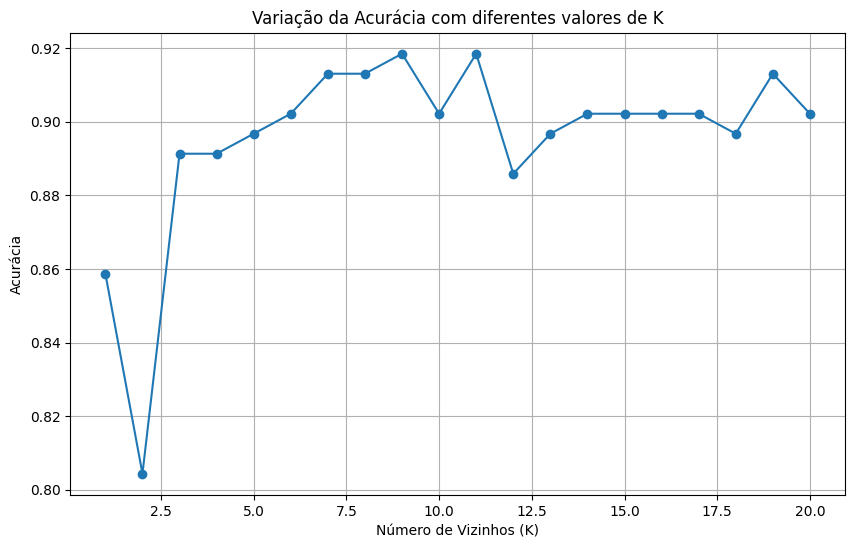

In [9]:
plt.figure(figsize=(10,6))
plt.plot(resultados_k['K'], resultados_k['Acuracia'], marker='o', linestyle='-')
plt.title('Variação da Acurácia com diferentes valores de K')
plt.xlabel('Número de Vizinhos (K)')
plt.ylabel('Acurácia')
plt.grid(True)
plt.show()

## Melhor Modelo e Avaliação Final

In [10]:
melhor_k = resultados_k.loc[resultados_k['Acuracia'].idxmax(), 'K']
print(f"Melhor valor de K encontrado: {int(melhor_k)}")

modelo_final = treinar_knn(X_treino_pad, y_treino, k=int(melhor_k))
acuracia_final = avaliar_modelo(modelo_final, X_validacao_pad, y_validacao)

print(f"Acurácia final do modelo com K={int(melhor_k)}: {acuracia_final:.2f}")

Melhor valor de K encontrado: 9
Acurácia final do modelo com K=9: 0.92
